In [2]:
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
CACHE_DIR = PROJECT_ROOT / 'cache'
HF_CACHE_DIR = CACHE_DIR / 'huggingface'
HF_DATASETS_CACHE_DIR = HF_CACHE_DIR / 'datasets'
TRANSFORMERS_CACHE_DIR = CACHE_DIR / 'transformers'
KAGGLEHUB_CACHE_DIR = CACHE_DIR / 'kagglehub'
NLTK_DATA_DIR = CACHE_DIR / 'nltk_data'
TORCH_CACHE_DIR = CACHE_DIR / 'torch'
KERAS_CACHE_DIR = CACHE_DIR / 'keras'

for cache_path in [CACHE_DIR, HF_CACHE_DIR, HF_DATASETS_CACHE_DIR, TRANSFORMERS_CACHE_DIR, KAGGLEHUB_CACHE_DIR, NLTK_DATA_DIR, TORCH_CACHE_DIR, KERAS_CACHE_DIR]:
    cache_path.mkdir(parents=True, exist_ok=True)

os.environ['HF_HOME'] = str(HF_CACHE_DIR)
os.environ['HF_DATASETS_CACHE'] = str(HF_DATASETS_CACHE_DIR)
os.environ['HUGGINGFACE_HUB_CACHE'] = str(HF_CACHE_DIR / 'hub')
os.environ['TRANSFORMERS_CACHE'] = str(TRANSFORMERS_CACHE_DIR)
os.environ['KAGGLEHUB_CACHE'] = str(KAGGLEHUB_CACHE_DIR)
os.environ['NLTK_DATA'] = str(NLTK_DATA_DIR)
os.environ['TORCH_HOME'] = str(TORCH_CACHE_DIR)
os.environ['KERAS_HOME'] = str(KERAS_CACHE_DIR)
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

import re
import json
import shutil
import joblib
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
from datasets import load_dataset

print('Using project cache folder:', CACHE_DIR)


Using project cache folder: g:\College\semester 8\Foundation of Natural Language Processing\AI-vs-Human-Text-Detection\cache


In [3]:
local_path = Path('data/raw/essay/AI_Human.csv')
local_path.parent.mkdir(parents=True, exist_ok=True)

if local_path.exists():
    print('Loading dataset from local file:', local_path)
else:
    print('Local dataset not found. Downloading...')
    downloaded_path = Path(kagglehub.dataset_download('shanegerami/ai-vs-human-text'))
    source_path = downloaded_path / 'AI_Human.csv'
    if not source_path.exists():
        source_path = next(downloaded_path.rglob('AI_Human.csv'))
    shutil.copy(source_path, local_path)
    print('Dataset saved locally:', local_path)

Loading dataset from local file: data\raw\essay\AI_Human.csv


In [4]:
df = pd.read_csv(local_path)
df.head()

,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   text       487235 non-null  object 
 1   generated  487235 non-null  float64
dtypes: float64(1), object(1)
memory usage: 7.4+ MB


In [6]:
df.rename(columns={"generated": "source"}, inplace=True)

In [7]:
df['text'][0]

'Cars. Cars have been around since they became famous in the 1900s, when Henry Ford created and built the first ModelT. Cars have played a major role in our every day lives since then. But now, people are starting to question if limiting car usage would be a good thing. To me, limiting the use of cars might be a good thing to do.\n\nIn like matter of this, article, "In German Suburb, Life Goes On Without Cars," by Elizabeth Rosenthal states, how automobiles are the linchpin of suburbs, where middle class families from either Shanghai or Chicago tend to make their homes. Experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe. Passenger cars are responsible for 12 percent of greenhouse gas emissions in Europe...and up to 50 percent in some carintensive areas in the United States. Cars are the main reason for the greenhouse gas emissions because of a lot of people driving them around all the time getting where they need to go. Article

<Axes: xlabel='source', ylabel='count'>

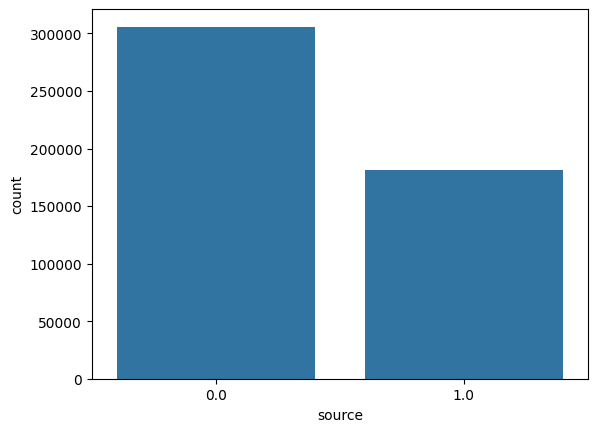

In [8]:
sns.countplot(data=df,x='source')

In [9]:
df['text'][0]

'Cars. Cars have been around since they became famous in the 1900s, when Henry Ford created and built the first ModelT. Cars have played a major role in our every day lives since then. But now, people are starting to question if limiting car usage would be a good thing. To me, limiting the use of cars might be a good thing to do.\n\nIn like matter of this, article, "In German Suburb, Life Goes On Without Cars," by Elizabeth Rosenthal states, how automobiles are the linchpin of suburbs, where middle class families from either Shanghai or Chicago tend to make their homes. Experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe. Passenger cars are responsible for 12 percent of greenhouse gas emissions in Europe...and up to 50 percent in some carintensive areas in the United States. Cars are the main reason for the greenhouse gas emissions because of a lot of people driving them around all the time getting where they need to go. Article

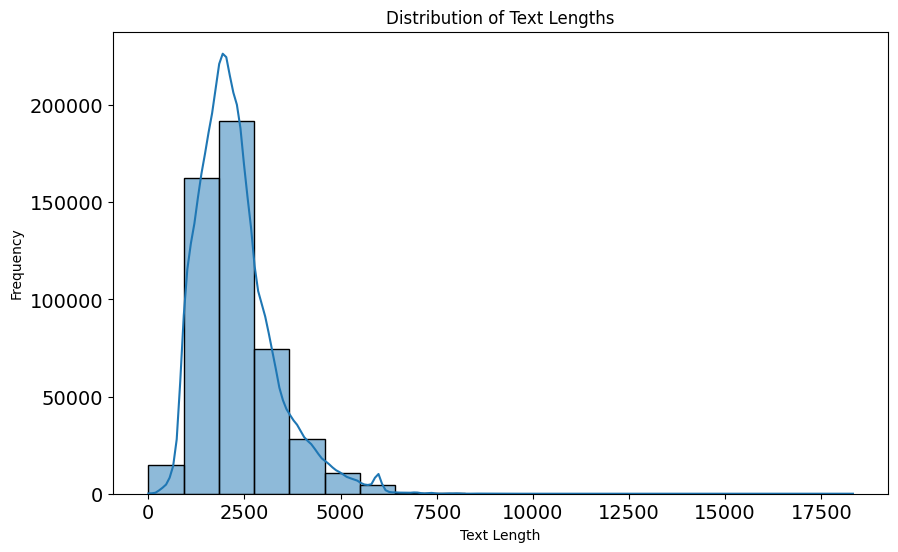

In [10]:
df['text_length'] = df['text'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=20, kde=True)
plt.title("Distribution of Text Lengths")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [11]:
df['text_length'].describe()

count    487235.000000
mean       2269.586592
std         988.814028
min           1.000000
25%        1583.000000
50%        2102.000000
75%        2724.000000
max       18322.000000
Name: text_length, dtype: float64

In [12]:
df = df.drop(columns=['text_length'])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   text    487235 non-null  object 
 1   source  487235 non-null  float64
dtypes: float64(1), object(1)
memory usage: 7.4+ MB


In [14]:
df['text'][0]

'Cars. Cars have been around since they became famous in the 1900s, when Henry Ford created and built the first ModelT. Cars have played a major role in our every day lives since then. But now, people are starting to question if limiting car usage would be a good thing. To me, limiting the use of cars might be a good thing to do.\n\nIn like matter of this, article, "In German Suburb, Life Goes On Without Cars," by Elizabeth Rosenthal states, how automobiles are the linchpin of suburbs, where middle class families from either Shanghai or Chicago tend to make their homes. Experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe. Passenger cars are responsible for 12 percent of greenhouse gas emissions in Europe...and up to 50 percent in some carintensive areas in the United States. Cars are the main reason for the greenhouse gas emissions because of a lot of people driving them around all the time getting where they need to go. Article

In [15]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[\U00010000-\U0010ffff]', ' ', text)
    text = re.sub(r"[^a-z0-9\s\.,!\?;:'-]", ' ', text)
    text = re.sub(r'(.)\1{4,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [16]:
df = df.drop_duplicates(subset='text').dropna(subset=['text'])
df['cleaned_text'] = df['text'].apply(clean_text)
df['word_count'] = df['cleaned_text'].str.split().str.len()
df = df[(df['cleaned_text'] != '') & (df['word_count'] >= 50)]
df = df.drop_duplicates(subset='cleaned_text').reset_index(drop=True)

In [17]:
df[['text', 'cleaned_text', 'word_count']].head()

,text,cleaned_text,word_count
0,Cars. Cars have been around since they became ...,cars. cars have been around since they became ...,584
1,Transportation is a large necessity in most co...,transportation is a large necessity in most co...,462
2,"""America's love affair with it's vehicles seem...",america's love affair with it's vehicles seems...,750
3,How often do you ride in a car? Do you drive a...,how often do you ride in a car? do you drive a...,686
4,Cars are a wonderful thing. They are perhaps o...,cars are a wonderful thing. they are perhaps o...,871


In [18]:
df['cleaned_text'][0]

"cars. cars have been around since they became famous in the 1900s, when henry ford created and built the first modelt. cars have played a major role in our every day lives since then. but now, people are starting to question if limiting car usage would be a good thing. to me, limiting the use of cars might be a good thing to do. in like matter of this, article, in german suburb, life goes on without cars, by elizabeth rosenthal states, how automobiles are the linchpin of suburbs, where middle class families from either shanghai or chicago tend to make their homes. experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe. passenger cars are responsible for 12 percent of greenhouse gas emissions in europe...and up to 50 percent in some carintensive areas in the united states. cars are the main reason for the greenhouse gas emissions because of a lot of people driving them around all the time getting where they need to go. article, par

In [19]:
df.head()

,text,source,cleaned_text,word_count
0,Cars. Cars have been around since they became ...,0.0,cars. cars have been around since they became ...,584
1,Transportation is a large necessity in most co...,0.0,transportation is a large necessity in most co...,462
2,"""America's love affair with it's vehicles seem...",0.0,america's love affair with it's vehicles seems...,750
3,How often do you ride in a car? Do you drive a...,0.0,how often do you ride in a car? do you drive a...,686
4,Cars are a wonderful thing. They are perhaps o...,0.0,cars are a wonderful thing. they are perhaps o...,871


In [20]:
top_words = Counter(" ".join(df[df['source'] == 0]['cleaned_text']).split()).most_common(10)
top_words

[('the', 5669880),
 ('to', 4126140),
 ('a', 2829698),
 ('and', 2715403),
 ('of', 2250242),
 ('in', 1955270),
 ('that', 1907082),
 ('is', 1749463),
 ('you', 1407519),
 ('it', 1355830)]

In [21]:
top_words = Counter(" ".join(df[df['source'] == 1]['cleaned_text']).split()).most_common(10)
top_words

[('the', 2607528),
 ('and', 2119590),
 ('to', 2113259),
 ('a', 1516363),
 ('of', 1499594),
 ('in', 1151594),
 ('that', 852517),
 ('is', 792956),
 ('for', 717239),
 ('can', 715593)]

In [22]:
import nltk
from nltk.tokenize import word_tokenize

nltk.data.path.insert(0, str(NLTK_DATA_DIR))
nltk.download('punkt', download_dir=str(NLTK_DATA_DIR))
nltk.download('punkt_tab', download_dir=str(NLTK_DATA_DIR), quiet=True)

df['tokenized_text'] = df['cleaned_text'].apply(word_tokenize)


[nltk_data] Downloading package punkt to g:\College\semester
[nltk_data]     8\Foundation of Natural Language Processing\AI-vs-
[nltk_data]     Human-Text-Detection\cache\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [23]:
from nltk.corpus import stopwords

nltk.download('stopwords', download_dir=str(NLTK_DATA_DIR))

viz_stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to g:\College\semester
[nltk_data]     8\Foundation of Natural Language Processing\AI-vs-
[nltk_data]     Human-Text-Detection\cache\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [24]:
df['viz_tokens_no_stopwords'] = df['tokenized_text'].apply(
    lambda tokens: [word for word in tokens if word.lower() not in viz_stop_words]
)

In [25]:
all_tokens = [token for tokens_list in df[df['source'] == 0]['viz_tokens_no_stopwords'] for token in tokens_list]
Counter(all_tokens).most_common(10)

[('.', 5670680),
 (',', 4505447),
 ('students', 840658),
 ('would', 832238),
 ('people', 811943),
 ("n't", 649479),
 ('school', 537239),
 ("'s", 535140),
 ('could', 428679),
 ('get', 406720)]

In [26]:
all_tokens = [token for tokens_list in df[df['source'] == 1]['viz_tokens_no_stopwords'] for token in tokens_list]
Counter(all_tokens).most_common(10)

[(',', 3709310),
 ('.', 3113556),
 ("'s", 380239),
 ('students', 341301),
 ('people', 270121),
 ('also', 237509),
 ('electoral', 219676),
 ('like', 202173),
 ('college', 201889),
 ('may', 190176)]

In [27]:
df['tokenized_text'][0]

['cars',
 '.',
 'cars',
 'have',
 'been',
 'around',
 'since',
 'they',
 'became',
 'famous',
 'in',
 'the',
 '1900s',
 ',',
 'when',
 'henry',
 'ford',
 'created',
 'and',
 'built',
 'the',
 'first',
 'modelt',
 '.',
 'cars',
 'have',
 'played',
 'a',
 'major',
 'role',
 'in',
 'our',
 'every',
 'day',
 'lives',
 'since',
 'then',
 '.',
 'but',
 'now',
 ',',
 'people',
 'are',
 'starting',
 'to',
 'question',
 'if',
 'limiting',
 'car',
 'usage',
 'would',
 'be',
 'a',
 'good',
 'thing',
 '.',
 'to',
 'me',
 ',',
 'limiting',
 'the',
 'use',
 'of',
 'cars',
 'might',
 'be',
 'a',
 'good',
 'thing',
 'to',
 'do',
 '.',
 'in',
 'like',
 'matter',
 'of',
 'this',
 ',',
 'article',
 ',',
 'in',
 'german',
 'suburb',
 ',',
 'life',
 'goes',
 'on',
 'without',
 'cars',
 ',',
 'by',
 'elizabeth',
 'rosenthal',
 'states',
 ',',
 'how',
 'automobiles',
 'are',
 'the',
 'linchpin',
 'of',
 'suburbs',
 ',',
 'where',
 'middle',
 'class',
 'families',
 'from',
 'either',
 'shanghai',
 'or',
 'chi

In [28]:
from nltk.stem import WordNetLemmatizer
import nltk

nltk.data.path.insert(0, str(NLTK_DATA_DIR))
nltk.download('wordnet', download_dir=str(NLTK_DATA_DIR))
nltk.download('omw-1.4', download_dir=str(NLTK_DATA_DIR), quiet=True)

lemmatizer = WordNetLemmatizer()

def lemmatize_text(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['lemmatized_text'] = df['tokenized_text'].apply(lemmatize_text)


[nltk_data] Downloading package wordnet to g:\College\semester
[nltk_data]     8\Foundation of Natural Language Processing\AI-vs-
[nltk_data]     Human-Text-Detection\cache\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [29]:
all_tokens = [token for tokens_list in df[df['source'] == 0]['lemmatized_text'] for token in tokens_list]
Counter(all_tokens).most_common(10)

[('the', 5677313),
 ('.', 5670680),
 (',', 4505447),
 ('to', 4157008),
 ('a', 3345971),
 ('and', 2727400),
 ('of', 2259865),
 ('that', 2025806),
 ('in', 1984892),
 ('is', 1820501)]

In [30]:
all_tokens = [token for tokens_list in df[df['source'] == 1]['lemmatized_text'] for token in tokens_list]
Counter(all_tokens).most_common(10)

[(',', 3709310),
 ('.', 3113556),
 ('the', 2608988),
 ('and', 2130629),
 ('to', 2119673),
 ('a', 1904339),
 ('of', 1502291),
 ('in', 1158654),
 ('that', 882936),
 ('it', 809001)]

In [31]:
import gc

Path('data').mkdir(exist_ok=True)
MODEL_DATA_PATH = Path('data/essay_model.pkl')
modeling_df = df[['cleaned_text', 'source']].copy()
modeling_df['source'] = modeling_df['source'].astype('int8')
modeling_df.to_pickle(MODEL_DATA_PATH)

heavy_columns = ['text', 'word_count', 'tokenized_text', 'viz_tokens_no_stopwords', 'lemmatized_text']
df = modeling_df
for name in ['modeling_df', 'all_tokens']:
    if name in globals():
        del globals()[name]
gc.collect()

print(f'Saved compact modeling data to {MODEL_DATA_PATH}')
print('Current df columns:', df.columns.tolist())
print('Rows:', len(df))


Saved compact modeling data to data\essay_model.pkl
Current df columns: ['cleaned_text', 'source']
Rows: 464064


In [32]:
import gc

MODEL_DATA_PATH = Path('data/essay_model.pkl')
required_columns = {'cleaned_text', 'source'}

if 'df' in globals() and required_columns.issubset(df.columns):
    df = df[['cleaned_text', 'source']].copy()
    df['source'] = df['source'].astype('int8')
    print('Using existing in-memory compact df; no file was read.')
elif MODEL_DATA_PATH.exists():
    df = pd.read_pickle(MODEL_DATA_PATH)
    print('Loaded compact modeling data from:', MODEL_DATA_PATH)
else:
    raise FileNotFoundError(
        f'{MODEL_DATA_PATH} does not exist. Run the preprocessing/save cell first. '
        'The old data/essay.pkl can be too large to load safely.'
    )

gc.collect()
print(df.info(memory_usage='deep'))


Using existing in-memory compact df; no file was read.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464064 entries, 0 to 464063
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   cleaned_text  464064 non-null  object
 1   source        464064 non-null  int8  
dtypes: int8(1), object(1)
memory usage: 1.0 GB
None


In [33]:
X = df['cleaned_text']
y = df['source']

In [34]:
X.head()

0    cars. cars have been around since they became ...
1    transportation is a large necessity in most co...
2    america's love affair with it's vehicles seems...
3    how often do you ride in a car? do you drive a...
4    cars are a wonderful thing. they are perhaps o...
Name: cleaned_text, dtype: object

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [36]:
print(len(X_train))
print(len(y_train))

324844
324844


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost.core import XGBoostError
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [38]:
def make_tfidf_pipeline(classifier, **tfidf_overrides):
    tfidf_params = {
        'ngram_range': (1, 2),
        'min_df': 2,
        'max_df': 0.95,
        'sublinear_tf': True,
        'dtype': np.float32
    }
    tfidf_params.update(tfidf_overrides)
    return Pipeline([
        ('tfidf', TfidfVectorizer(**tfidf_params)),
        ('classifier', classifier)
    ])

pipelines = {
    'Naive Bayes': make_tfidf_pipeline(MultinomialNB()),
    'Logistic Regression': make_tfidf_pipeline(LogisticRegression(max_iter=1000)),
    'Passive Aggressive': make_tfidf_pipeline(PassiveAggressiveClassifier(max_iter=1000, random_state=42)),
    'Random Forest': make_tfidf_pipeline(
        RandomForestClassifier(
            n_estimators=50,
            max_depth=40,
            min_samples_leaf=2,
            n_jobs=-1,
            random_state=42
        ),
        ngram_range=(1, 1),
        min_df=5,
        max_features=20000
    ),
    'XGBoost': make_tfidf_pipeline(
        XGBClassifier(
            booster='gblinear',
            objective='binary:logistic',
            eval_metric='logloss',
            n_estimators=50,
            learning_rate=0.1,
            n_jobs=1,
            random_state=42
        ),
        ngram_range=(1, 1),
        min_df=10,
        max_features=10000
    )
}

ml_model_files = {
    'Naive Bayes': 'essay_naive_bayes.pkl',
    'Logistic Regression': 'essay_logistic_regression.pkl',
    'Passive Aggressive': 'essay_passive_aggressive.pkl',
    'Random Forest': 'essay_random_forest.pkl',
    'XGBoost': 'essay_xgboost.pkl'
}


In [38]:
ml_metrics = []
trained_ml_pipelines = {}

for model_name, pipeline in pipelines.items():
    try:
        pipeline.fit(X_train, y_train)
    except (MemoryError, XGBoostError) as exc:
        print(f'Skipping {model_name}: not enough memory to train this model on the current dataset.')
        print(exc)
        continue

    y_pred = pipeline.predict(X_test)
    trained_ml_pipelines[model_name] = pipeline

    ml_metrics.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0)
    })

    print(model_name)
    print(classification_report(y_test, y_pred))


Naive Bayes
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     85313
           1       1.00      0.94      0.97     53907

    accuracy                           0.97    139220
   macro avg       0.98      0.97      0.97    139220
weighted avg       0.98      0.97      0.97    139220

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     85313
           1       1.00      0.99      0.99     53907

    accuracy                           1.00    139220
   macro avg       1.00      1.00      1.00    139220
weighted avg       1.00      1.00      1.00    139220

Passive Aggressive
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85313
           1       1.00      1.00      1.00     53907

    accuracy                           1.00    139220
   macro avg       1.00      1.00      1.00    139220
weighted avg       1.00

In [39]:
ml_metrics_df = pd.DataFrame(ml_metrics).sort_values('f1', ascending=False)
ml_metrics_df

,model,accuracy,precision,recall,f1
2,Passive Aggressive,0.999741,0.999740,0.999592,0.999666
4,XGBoost,0.999145,0.999313,0.998479,0.998896
1,Logistic Regression,0.996085,0.998394,0.991485,0.994927
3,Random Forest,0.994512,0.999417,0.986403,0.992867
0,Naive Bayes,0.974874,0.997120,0.937819,0.966561


In [40]:
model_dir = Path('models/essay/ml')
model_dir.mkdir(parents=True, exist_ok=True)

for model_name, pipeline in trained_ml_pipelines.items():
    joblib.dump(pipeline, model_dir / ml_model_files[model_name])

In [41]:
metrics_dir = Path('models/essay')
metrics_dir.mkdir(parents=True, exist_ok=True)

ml_metrics_df.to_csv(metrics_dir / 'essay_ml_metrics.csv', index=False)
with open(metrics_dir / 'essay_ml_metrics.json', 'w', encoding='utf-8') as file:
    json.dump(ml_metrics, file, indent=2)

In [ ]:
import gc

legacy_model_dir = Path('models')
legacy_model_dir.mkdir(exist_ok=True)

pa_pipeline = trained_ml_pipelines.get('Passive Aggressive')
if pa_pipeline is not None:
    legacy_path = legacy_model_dir / 'essay_passive_aggressive_pipeline.pkl'
    joblib.dump(pa_pipeline, legacy_path)
    print('Passive Aggressive legacy pipeline saved to:', legacy_path)
else:
    print('Passive Aggressive was not trained, so the legacy pipeline was not saved.')

for name in [
    'nb_pipeline', 'logreg_pipeline', 'pa_pipeline', 'rf_pipeline', 'xgb_pipeline',
    'trained_ml_pipelines', 'pipelines', 'pipeline', 'X', 'y', 'X_train', 'X_test', 'y_train', 'y_test',
    'ml_metrics', 'ml_metrics_df', 'y_pred'
]:
    if name in globals():
        del globals()[name]

gc.collect()
print('Released ML training objects from memory.')


The following section is designated for deep learning models.

In [40]:
print(type(df['cleaned_text'][0]))
print(df['cleaned_text'][0])

<class 'str'>
cars. cars have been around since they became famous in the 1900s, when henry ford created and built the first modelt. cars have played a major role in our every day lives since then. but now, people are starting to question if limiting car usage would be a good thing. to me, limiting the use of cars might be a good thing to do. in like matter of this, article, in german suburb, life goes on without cars, by elizabeth rosenthal states, how automobiles are the linchpin of suburbs, where middle class families from either shanghai or chicago tend to make their homes. experts say how this is a huge impediment to current efforts to reduce greenhouse gas emissions from tailpipe. passenger cars are responsible for 12 percent of greenhouse gas emissions in europe...and up to 50 percent in some carintensive areas in the united states. cars are the main reason for the greenhouse gas emissions because of a lot of people driving them around all the time getting where they need to go.

In [41]:
from sklearn.model_selection import train_test_split
import gc
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

texts = df['cleaned_text'].astype(str).tolist()
y = df['source'].astype('int8').values
max_vocab_size = 10000
max_len = int(np.percentile([len(text.split()) for text in texts], 95))
max_len = max(50, min(max_len, 500))

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token='<OOV>', filters='', lower=False)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
del sequences
gc.collect()

X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, y, test_size=0.3, random_state=42, stratify=y
)
del padded_sequences, y, texts
gc.collect()

X_train_tensor = torch.tensor(X_train, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
del X_train, X_test, y_train, y_test
gc.collect()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

vocab_size = max_vocab_size + 1
label_mapping = {'human': 0, 'ai': 1}
print(f"Vocabulary size for embedding: {vocab_size}")
print(f"Sequence length: {max_len}")


Vocabulary size for embedding: 10001
Sequence length: 500


In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import RobertaModel, ElectraModel

vocab_size = 29500  
embed_dim = 100    
hidden_dim=64                        

class DNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(DNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.global_avg_pool = lambda x: torch.mean(x, dim=1) 
        self.fc1 = nn.Linear(embed_dim, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)             
        x = self.global_avg_pool(x)       
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.output(x)
        return x




class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(BiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        self.output = nn.Linear(2 * hidden_dim, output_dim) 

    def forward(self, x):
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        x = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)
        x = self.output(x) 
        return x


class CNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(CNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.conv1d = nn.Conv1d(in_channels=embed_dim, out_channels=128, kernel_size=5)
        self.global_max_pool = nn.AdaptiveMaxPool1d(1)  
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x)  
        x = x.permute(0, 2, 1) 
        x = torch.relu(self.conv1d(x))
        x = self.global_max_pool(x).squeeze(-1)  
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, gru_hidden_dim, num_classes):
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, gru_hidden_dim, batch_first=True) 
        self.fc1 = nn.Linear(gru_hidden_dim, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, num_classes)
        
    def forward(self, x):
        x = self.embedding(x)                 
        _, hn = self.gru(x)                   
        x = hn[-1]                            
        x = torch.relu(self.fc1(x))           
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))           
        x = self.output(x)                    
        return x
    

g:\programs\Python\Python310\lib\site-packages\transformers\utils\hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelBinarizer

def evaluate_model(model, data_loader, device):
    model.eval()
    all_labels_list, all_preds_list, all_probs_raw_list = [], [], []

    num_classes = 0
    if hasattr(model, 'output'):
        num_classes = model.output.out_features
    elif hasattr(model, 'fc2'):
        num_classes = model.fc2.out_features
    elif hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
        num_classes = model.fc.out_features
    else:
        raise AttributeError("Could not determine num_classes from model's output layer (expected 'output', 'fc2', or 'fc').")

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            if labels.dim() == 2 and labels.size(1) == 1:
                labels = labels.squeeze(1)

            outputs = model(inputs)

            if num_classes > 1:
                probs = F.softmax(outputs, dim=1)
                all_probs_raw_list.extend(probs.cpu().numpy())
                
                _, preds = torch.max(outputs, 1)
                all_preds_list.extend(preds.cpu().numpy())
                all_labels_list.extend(labels.cpu().numpy())
            else: 
                outputs_sigmoid = torch.sigmoid(outputs)
                probs = outputs_sigmoid.cpu().numpy()
                all_probs_raw_list.extend(probs.flatten()) 
                
                preds = (outputs_sigmoid >= 0.5).float().cpu().numpy()
                all_preds_list.extend(preds.flatten())
                all_labels_list.extend(labels.cpu().numpy().flatten())

    all_labels = np.array(all_labels_list).flatten().astype(int) 
    all_preds = np.array(all_preds_list).flatten().astype(int)

    if num_classes == 2:
        all_probs_for_auc = np.array(all_probs_raw_list) 
        if all_probs_for_auc.ndim == 2: 
            all_probs_for_auc = all_probs_for_auc[:, 1]
        elif all_probs_for_auc.ndim == 1 and np.unique(all_labels).size == 2: 
            pass 
        else:
            print("Warning: Unexpected shape for all_probs_raw_list in binary evaluation. Reshaping to 1D.")
            all_probs_for_auc = all_probs_for_auc.flatten()
            
    elif num_classes > 2:
        all_probs_for_auc = np.array(all_probs_raw_list) 
        if all_probs_for_auc.ndim == 1 and num_classes > 1: 
            print(f"Warning: all_probs_raw_list is 1D for multi-class {num_classes}. This is likely incorrect for AUC.")

            
    else: 
        all_probs_for_auc = np.array(all_probs_raw_list).flatten() 


    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    roc_auc = float('nan')
    if num_classes == 2:
        try:
            roc_auc = roc_auc_score(all_labels, all_probs_for_auc)
        except ValueError:
            roc_auc = 0.0
    elif num_classes > 2:
        if all_probs_for_auc.shape == (len(all_labels), num_classes):
            try:
                roc_auc = roc_auc_score(all_labels, all_probs_for_auc, multi_class='ovr', average='weighted')
            except ValueError:
                roc_auc = 0.0
        else:
            print(f"Warning: all_probs_for_auc shape {all_probs_for_auc.shape} mismatch with expected ({len(all_labels)}, {num_classes}) for multi-class AUC.")

    cm = confusion_matrix(all_labels, all_preds)

    print(f"Evaluation - Accuracy:  {accuracy:.4f}")
    print(f"Evaluation - Precision: {precision:.4f}")
    print(f"Evaluation - Recall:    {recall:.4f}")
    print(f"Evaluation - F1 Score:  {f1:.4f}")
    if not np.isnan(roc_auc):
        print(f"Evaluation - AUC-ROC:   {roc_auc:.4f}")
    else:
        print("Evaluation - AUC-ROC:   Not applicable or calculation failed for AUC-ROC.")

    return all_labels, all_probs_for_auc, cm


def plot_confusion_matrix(cm, labels=None):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


def plot_roc_curve(y_true, y_probs, num_classes, class_labels=None):
    y_true = np.array(y_true).flatten().astype(int)

    if num_classes == 2:
        if y_probs.ndim > 1 and y_probs.shape[1] == 2:
            y_probs = y_probs[:, 1]
        elif y_probs.ndim > 1 and y_probs.shape[1] == 1:
            y_probs = y_probs.flatten() 

        fpr, tpr, _ = roc_curve(y_true, y_probs)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
    elif num_classes > 2:
        print("\nPlotting One-vs-Rest ROC Curves for multi-class.")
        plt.figure(figsize=(8, 7))
        
        lb = LabelBinarizer()
        y_true_bin = lb.fit_transform(y_true) 
        
        if y_probs.ndim != 2 or y_probs.shape[1] != num_classes:
             print(f"Warning: y_probs shape {y_probs.shape} is not (n_samples, {num_classes}) for multi-class One-vs-Rest ROC plotting. Skipping.")
             return

        for i in range(num_classes):
            if y_true_bin[:, i].sum() == 0 and y_probs[:, i].sum() == 0:
                continue

            try:
                fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
                class_roc_auc = auc(fpr, tpr)
            except ValueError as e:
                print(f"Could not plot ROC for class {i} ({class_labels[i] if class_labels else ''}): {e}")
                continue

            label_name = class_labels[i] if class_labels and i < len(class_labels) else f"Class {i}"
            plt.plot(fpr, tpr, label=f'{label_name} (AUC = {class_roc_auc:.2f})')

        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('One-vs-Rest ROC Curve')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()
    else:
        print(f"ROC Curve plotting is typically for binary or multi-class (One-vs-Rest). Your model has {num_classes} class(es).")


def train_model(model, train_loader, test_loader, device, model_name="Model", epochs=5):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    train_losses, test_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            if labels.dim() == 2 and labels.size(1) == 1:
                labels = labels.squeeze(1)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                if labels.dim() == 2 and labels.size(1) == 1:
                    labels = labels.squeeze(1)

                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)

                correct += (predicted == labels).sum().item()
                total += labels.size(0)
        
        accuracy = correct / total
        test_accuracies.append(accuracy)
        print(f"{model_name} - Epoch {epoch+1}/{epochs}, Loss: {train_losses[-1]:.4f}, Accuracy: {accuracy:.4f}")

    print("\n--- Model Evaluation ---")
    
    num_classes = 0
    if hasattr(model, 'output'):
        num_classes = model.output.out_features
    elif hasattr(model, 'fc2'):
        num_classes = model.fc2.out_features
    elif hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
        num_classes = model.fc.out_features
    else:
        print("Warning: Could not determine num_classes from known output layer names. Defaulting to 2.")
        num_classes = 2

    class_labels = None
    if 'y_test' in globals() and y_test is not None:
        unique_labels = sorted(np.unique(y_test))
        class_labels = [str(int(label)) for label in unique_labels]
        if num_classes != len(unique_labels):
            print(f"Warning: Model's output_dim ({num_classes}) does not match number of unique labels in y_test ({len(unique_labels)}). Adjusting for plotting consistency.")

            pass 
    else:
        print("Warning: y_test not found or is None. Cannot determine class labels for plotting.")
        class_labels = [str(i) for i in range(num_classes)]

    try:
        actual_labels, predicted_probs, confusion_matrix_result = evaluate_model(model, test_loader, device)
        
        plot_confusion_matrix(confusion_matrix_result, labels=class_labels)

        plot_roc_curve(actual_labels, predicted_probs, num_classes=num_classes, class_labels=class_labels)

    except Exception as e:
        print(f"An error occurred during evaluation or plotting: {e}")

    return model, train_losses, test_accuracies

In [ ]:
print(f"Max token in input: {X_train_tensor.max().item()}")
print(f"Vocab size: {vocab_size}")

Max token in input: 9999
Vocab size: 29500


In [ ]:
print(torch.unique(y_train_tensor))
print(torch.unique(y_test_tensor))

tensor([0, 1])
tensor([0, 1])


In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TextCNN - Epoch 1/5, Loss: 0.0387, Accuracy: 0.9974
TextCNN - Epoch 2/5, Loss: 0.0095, Accuracy: 0.9988
TextCNN - Epoch 3/5, Loss: 0.0064, Accuracy: 0.9994
TextCNN - Epoch 4/5, Loss: 0.0043, Accuracy: 0.9994
TextCNN - Epoch 5/5, Loss: 0.0037, Accuracy: 0.9991

--- Model Evaluation ---
Evaluation - Accuracy:  0.9991
Evaluation - Precision: 0.9991
Evaluation - Recall:    0.9991
Evaluation - F1 Score:  0.9991
Evaluation - AUC-ROC:   1.0000


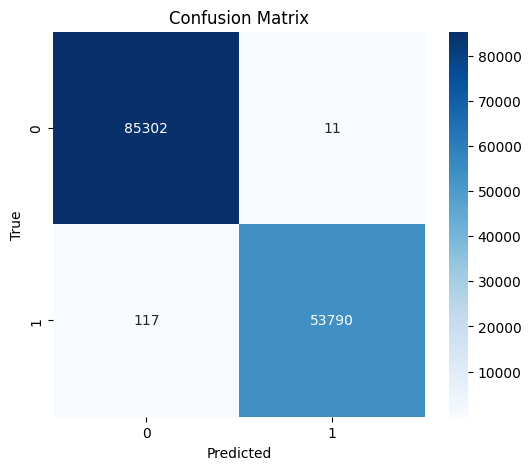

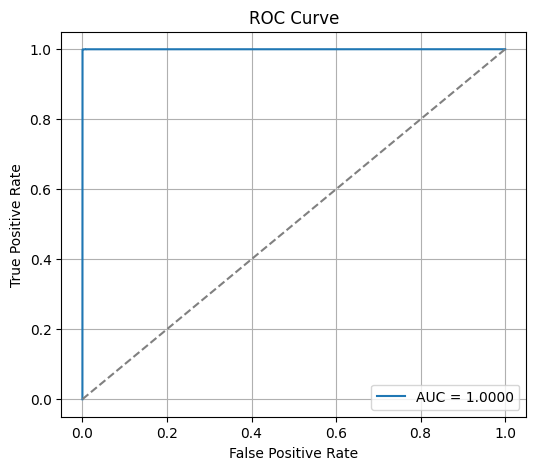

In [52]:
num_classes_CNN = df['source'].nunique()

cnn_model = CNNModel(
    vocab_size=vocab_size,
    embed_dim=128,
    num_classes=num_classes_CNN
).to(device)
trained_cnn, cnn_losses, cnn_accs = train_model(
    cnn_model,
    train_loader,
    test_loader,
    device,
    model_name='TextCNN',
    epochs=5
)
dl_history = {'cnn': {'loss': cnn_losses, 'accuracy': cnn_accs}}

In [53]:
dl_dir = Path('models/essay/dl')
dl_dir.mkdir(parents=True, exist_ok=True)
torch.save(trained_cnn.state_dict(), dl_dir / 'essay_cnn.pt')

BI-LSTM - Epoch 1/5, Loss: 0.0728, Accuracy: 0.9960
BI-LSTM - Epoch 2/5, Loss: 0.0098, Accuracy: 0.9971
BI-LSTM - Epoch 3/5, Loss: 0.0036, Accuracy: 0.9982
BI-LSTM - Epoch 4/5, Loss: 0.0019, Accuracy: 0.9989
BI-LSTM - Epoch 5/5, Loss: 0.0014, Accuracy: 0.9992

--- Model Evaluation ---
Evaluation - Accuracy:  0.9992
Evaluation - Precision: 0.9992
Evaluation - Recall:    0.9992
Evaluation - F1 Score:  0.9992
Evaluation - AUC-ROC:   1.0000


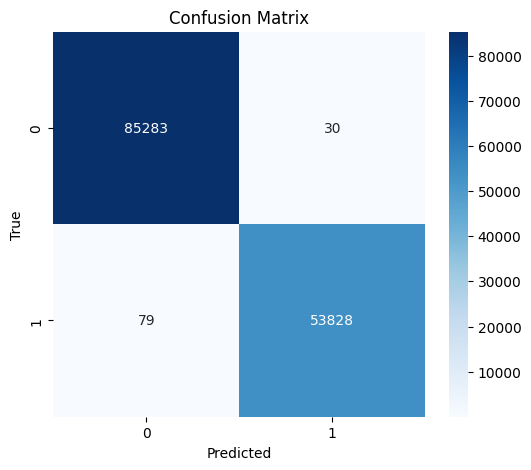

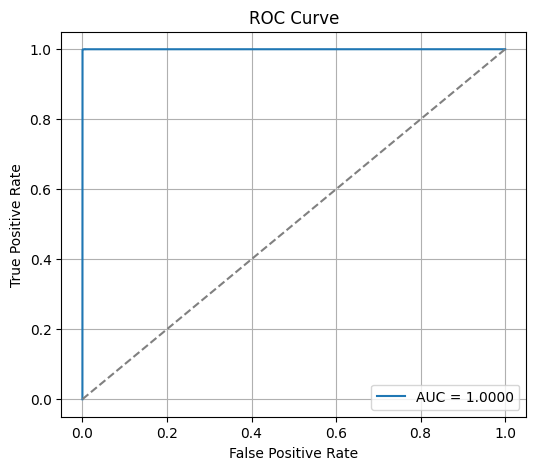

In [54]:
num_classes_BiLSTM = df['source'].nunique()
bilstm_model = BiLSTMModel(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=64,
    output_dim=num_classes_BiLSTM
).to(device)
trained_bilstm, bilstm_losses, bilstm_accs = train_model(
    bilstm_model, train_loader, test_loader, device, model_name='BI-LSTM', epochs=5
)
dl_history['bilstm'] = {'loss': bilstm_losses, 'accuracy': bilstm_accs}

In [55]:
torch.save(trained_bilstm.state_dict(), dl_dir / 'essay_bilstm.pt')

GRU - Epoch 1/5, Loss: 0.0685, Accuracy: 0.9980
GRU - Epoch 2/5, Loss: 0.0053, Accuracy: 0.9990
GRU - Epoch 3/5, Loss: 0.0031, Accuracy: 0.9992
GRU - Epoch 4/5, Loss: 0.0022, Accuracy: 0.9992
GRU - Epoch 5/5, Loss: 0.0020, Accuracy: 0.9994

--- Model Evaluation ---
Evaluation - Accuracy:  0.9994
Evaluation - Precision: 0.9994
Evaluation - Recall:    0.9994
Evaluation - F1 Score:  0.9994
Evaluation - AUC-ROC:   1.0000


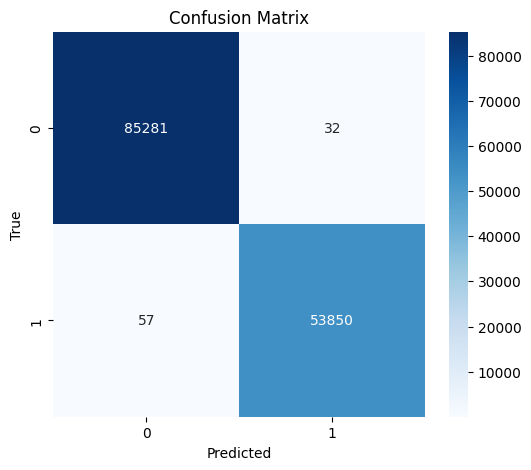

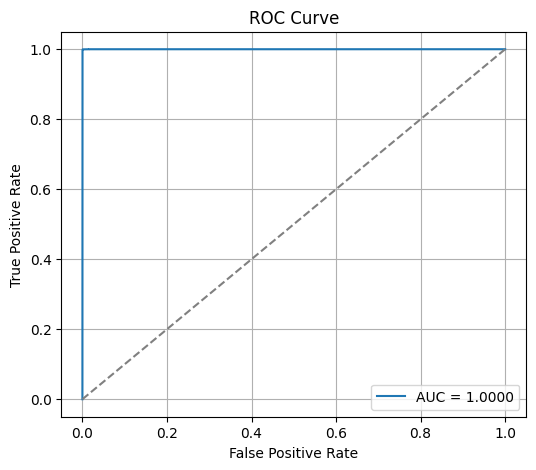

In [56]:
num_classes_GRU = df['source'].nunique()
gru_model = GRUModel(
    vocab_size=vocab_size,
    embed_dim=128,
    gru_hidden_dim=128,
    num_classes=num_classes_GRU
).to(device)
trained_gru, gru_losses, gru_accs = train_model(
    gru_model, train_loader, test_loader, device, model_name='GRU', epochs=5
)
dl_history['gru'] = {'loss': gru_losses, 'accuracy': gru_accs}

In [57]:
torch.save(trained_gru.state_dict(), dl_dir / 'essay_gru.pt')

DNN - Epoch 1/5, Loss: 0.0491, Accuracy: 0.9962
DNN - Epoch 2/5, Loss: 0.0121, Accuracy: 0.9974
DNN - Epoch 3/5, Loss: 0.0064, Accuracy: 0.9989
DNN - Epoch 4/5, Loss: 0.0042, Accuracy: 0.9991
DNN - Epoch 5/5, Loss: 0.0027, Accuracy: 0.9992

--- Model Evaluation ---
Evaluation - Accuracy:  0.9992
Evaluation - Precision: 0.9992
Evaluation - Recall:    0.9992
Evaluation - F1 Score:  0.9992
Evaluation - AUC-ROC:   1.0000


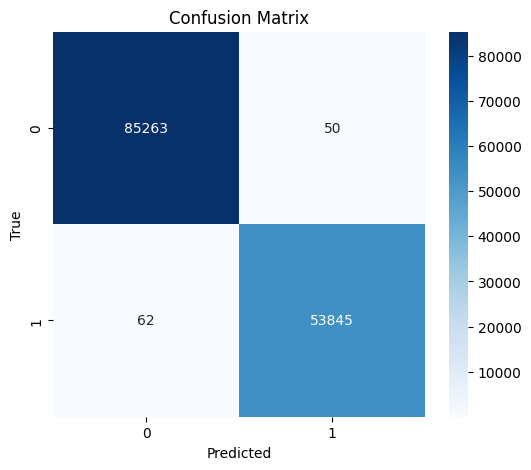

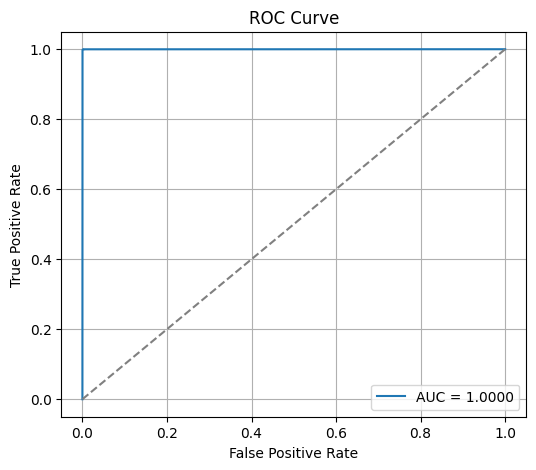

In [58]:
num_classes_DNN = df['source'].nunique()
dnn_model = DNNModel(
    vocab_size=vocab_size,
    embed_dim=128,
    num_classes=num_classes_DNN
).to(device)
trained_dnn, dnn_losses, dnn_accs = train_model(
    dnn_model, train_loader, test_loader, device, model_name='DNN', epochs=5
)
dl_history['dnn'] = {'loss': dnn_losses, 'accuracy': dnn_accs}

In [59]:
import gc

torch.save(trained_dnn.state_dict(), dl_dir / 'essay_dnn.pt')
joblib.dump(tokenizer, dl_dir / 'essay_tokenizer.pkl')

essay_dl_config = {
    'max_vocab_size': max_vocab_size,
    'vocab_size': vocab_size,
    'max_len': max_len,
    'padding': 'post',
    'truncating': 'post',
    'label_mapping': label_mapping,
    'preprocessing': 'clean_text',
    'models': {
        'cnn': {'file': 'essay_cnn.pt', 'embed_dim': 128, 'num_classes': int(num_classes_CNN)},
        'bilstm': {'file': 'essay_bilstm.pt', 'embed_dim': 128, 'hidden_dim': 64, 'num_classes': int(num_classes_BiLSTM)},
        'gru': {'file': 'essay_gru.pt', 'embed_dim': 128, 'gru_hidden_dim': 128, 'num_classes': int(num_classes_GRU)},
        'dnn': {'file': 'essay_dnn.pt', 'embed_dim': 128, 'num_classes': int(num_classes_DNN)}
    }
}

with open(dl_dir / 'essay_dl_config.json', 'w', encoding='utf-8') as file:
    json.dump(essay_dl_config, file, indent=2)

pd.DataFrame([
    {'model': name, 'final_loss': values['loss'][-1], 'final_accuracy': values['accuracy'][-1]}
    for name, values in dl_history.items()
]).to_csv(metrics_dir / 'essay_dl_metrics.csv', index=False)

with open(metrics_dir / 'essay_dl_metrics.json', 'w', encoding='utf-8') as file:
    json.dump(dl_history, file, indent=2)

for name in [
    'trained_cnn', 'trained_bilstm', 'trained_gru', 'trained_dnn',
    'cnn_model', 'bilstm_model', 'gru_model', 'dnn_model',
    'train_loader', 'test_loader', 'train_dataset', 'test_dataset',
    'X_train_tensor', 'X_test_tensor', 'y_train_tensor', 'y_test_tensor',
    'cnn_losses', 'cnn_accs', 'bilstm_losses', 'bilstm_accs', 'gru_losses', 'gru_accs', 'dnn_losses', 'dnn_accs'
]:
    if name in globals():
        del globals()[name]

if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
print('Saved DL artifacts and released DL training objects from memory.')


Saved DL artifacts and released DL training objects from memory.


In [ ]:
import gc

MODEL_DATA_PATH = Path('data/essay_model.pkl')
required_columns = {'cleaned_text', 'source'}

if 'df' in globals() and required_columns.issubset(df.columns):
    df = df[['cleaned_text', 'source']].copy()
    df['source'] = df['source'].astype('int8')
    print('Using existing in-memory compact df for transformers; no file was read.')
elif MODEL_DATA_PATH.exists():
    df = pd.read_pickle(MODEL_DATA_PATH)
    print('Loaded compact modeling data from:', MODEL_DATA_PATH)
else:
    raise FileNotFoundError(
        f'{MODEL_DATA_PATH} does not exist. Run the preprocessing/save cell first. '
        'The old data/essay.pkl can be too large to load safely.'
    )

gc.collect()


Using existing in-memory compact df for transformers; no file was read.


166

In [ ]:
df.head()

,cleaned_text,source
0,cars. cars have been around since they became ...,0
1,transportation is a large necessity in most co...,0
2,america's love affair with it's vehicles seems...,0
3,how often do you ride in a car? do you drive a...,0
4,cars are a wonderful thing. they are perhaps o...,0


In [46]:
from transformers import (
    RobertaTokenizer,
    ElectraTokenizer
)
from TransformersTraining import build_roberta, build_electra, split_dataframe, train_Transformers
transformer_dir = Path('models/essay/transformers')
transformer_dir.mkdir(parents=True, exist_ok=True)
train_df, val_df, test_df = split_dataframe(df)

Epoch 1:   5%|▍         | 999/20303 [08:02<2:32:17,  2.11it/s, loss=0.224]  


Saved checkpoint at iter 1000: models\essay\transformers\roberta\ckpt_iter1000.pt


Epoch 1:   5%|▍         | 1000/20303 [09:41<162:34:15, 30.32s/it, loss=0.224, avg_train_loss=0.341, val_loss=0.102]


Saved improved checkpoint: models\essay\transformers\roberta\best_iter1000_val_0.1018.pt


Epoch 1:  10%|▉         | 1999/20303 [17:53<2:24:31,  2.11it/s, loss=0.00229]                                      

...


Saved checkpoint at iter 59000: models\essay\transformers\roberta\ckpt_iter59000.pt


Epoch 3:  96%|█████████▌| 19393/20303 [2:52:56<07:21,  2.06it/s, loss=0.0394]                                           


Saved checkpoint at iter 60000: models\essay\transformers\roberta\ckpt_iter60000.pt


Epoch 3: 100%|██████████| 20303/20303 [3:01:22<00:00,  1.87it/s, loss=0.0606]                                         


Epoch 3 validation loss: 0.0695


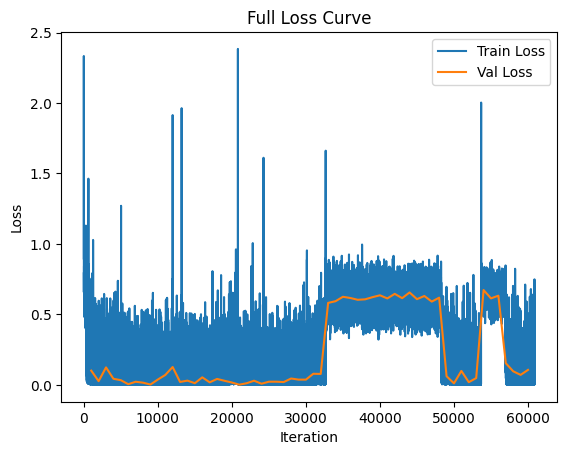

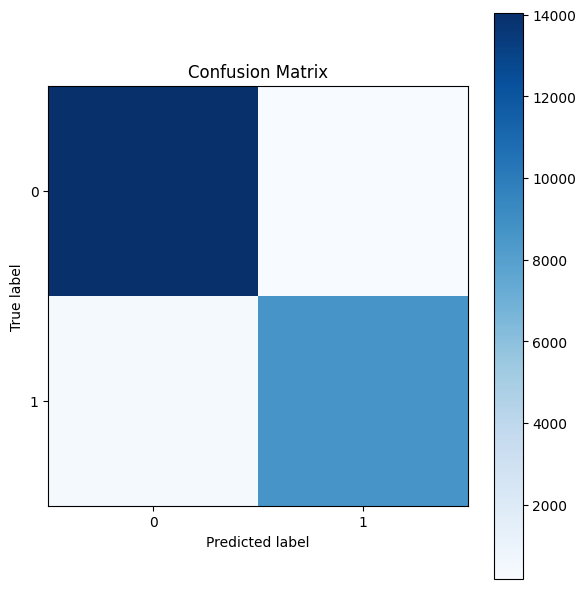

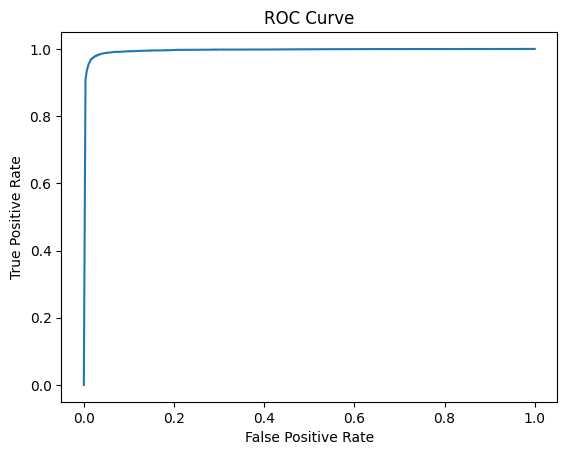

Released RoBERTa objects from memory.


In [73]:
roberta = build_roberta()
roberta_tokenizer = RobertaTokenizer.from_pretrained(
    'roberta-base',
    cache_dir=str(TRANSFORMERS_CACHE_DIR)
)
train_Transformers(
    roberta,
    roberta_tokenizer,
    train_df,
    val_df,
    lr=2e-5,
    weight_decay=0.01,
    epochs=3,
    loss_check=1000,
    checkpoint_dir=transformer_dir / 'roberta'
)

del roberta, roberta_tokenizer
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
print('Released RoBERTa objects from memory.')


Epoch 1:   5%|▍         | 999/20303 [08:52<2:51:16,  1.88it/s, loss=0.0505] 


Saved checkpoint at iter 1000: models\essay\transformers\electra\ckpt_iter1000.pt


Epoch 1:   5%|▍         | 1000/20303 [11:59<304:41:04, 56.82s/it, loss=0.0505, avg_train_loss=0.314, val_loss=0.0768]


Saved improved checkpoint: models\essay\transformers\electra\best_iter1000_val_0.0768.pt


Epoch 1:  10%|▉         | 1999/20303 [20:56<2:48:01,  1.82it/s, loss=0.00495]                                        

...


Saved checkpoint at iter 59000: models\essay\transformers\electra\ckpt_iter59000.pt


Epoch 3:  96%|█████████▌| 19393/20303 [3:25:04<07:28,  2.03it/s, loss=0.716]                                        


Saved checkpoint at iter 60000: models\essay\transformers\electra\ckpt_iter60000.pt


Epoch 3: 100%|██████████| 20303/20303 [3:34:12<00:00,  1.58it/s, loss=0.632]                                        


Epoch 3 validation loss: 0.6683


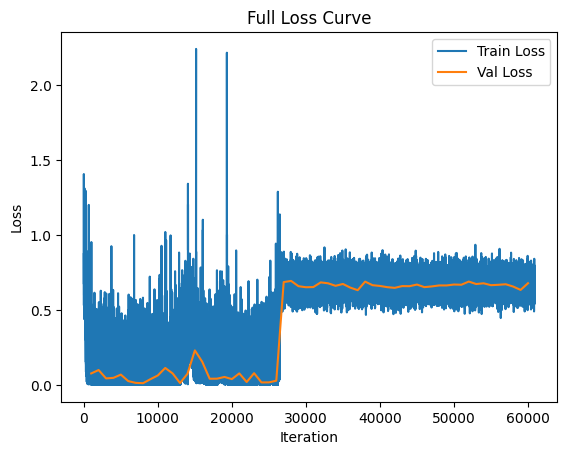

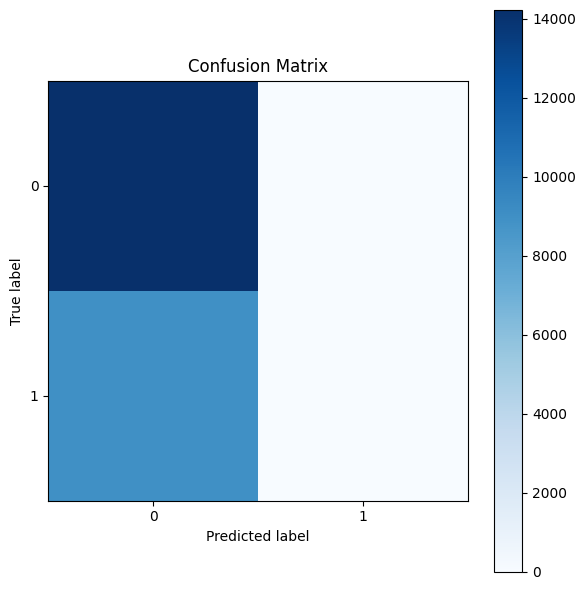

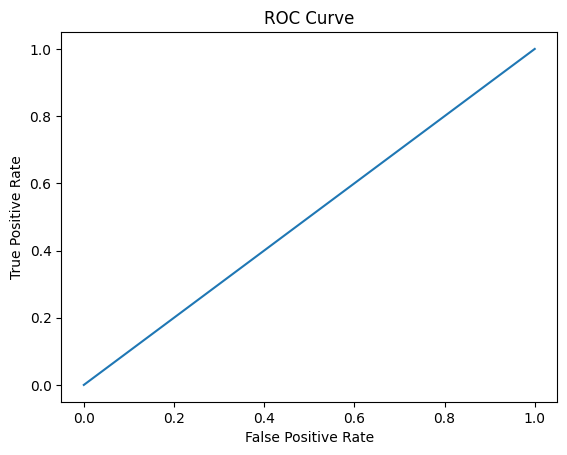

Released ELECTRA and transformer split objects from memory.


In [47]:
electra = build_electra()
electra_tokenizer = ElectraTokenizer.from_pretrained(
    'google/electra-base-discriminator',
    cache_dir=str(TRANSFORMERS_CACHE_DIR)
)
train_Transformers(
    electra,
    electra_tokenizer,
    train_df,
    val_df,
    lr=2e-5,
    weight_decay=0.01,
    epochs=3,
    loss_check=1000,
    checkpoint_dir=transformer_dir / 'electra'
)

del electra, electra_tokenizer, train_df, val_df, test_df
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()
print('Released ELECTRA and transformer split objects from memory.')


In [48]:
legacy_path = Path('models/essay_passive_aggressive_pipeline.pkl')
if legacy_path.exists():
    print('Legacy pipeline already saved at:', legacy_path)
else:
    model_path = Path('models/essay/ml/essay_passive_aggressive.pkl')
    if not model_path.exists():
        raise FileNotFoundError('Passive Aggressive model was not found. Run the ML training/save cells first.')
    legacy_path.parent.mkdir(exist_ok=True)
    pa_pipeline = joblib.load(model_path)
    joblib.dump(pa_pipeline, legacy_path)
    del pa_pipeline
    print('Pipeline saved to:', legacy_path)


Legacy pipeline already saved at: models\essay_passive_aggressive_pipeline.pkl
